# **<span style="color: #c9a84c;">𓅄Phase 2: CNN + N-gram Context Model</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation: Moving from Sign Classification to Automated Sentence Translation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 — Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 Phase 2 — Adding Sequential Context via N-gram Language Modeling</span>**

### **<span style="color: #c9a84c;">The Problem with Phase 1</span>**

<span style="color: #e8d5a3;">In Phase 1, our resnet CNN achieved 82.66% top-1 accuracy by classifying each hieroglyph **in complete isolation** — it looked at one image and predicted one label, blind to what surrounded it. But ancient Egyptian hieroglyphs are a **language**, not a collection of isolated symbols. The same physical glyph 𓅓 (owl) could represent the sound /m/, the word "owl", or a silent classifier indicating the preceding word relates to birds — and which function it serves depends entirely on the **surrounding signs**.</span>

<span style="color: #e8d5a3;">This means roughly 17% of the CNN's errors could potentially be corrected if we knew what other signs were nearby. Phase 2 exploits this by combining visual predictions with **statistical language patterns**.</span>

### **<span style="color: #c9a84c;">How N-grams Solve This</span>**

<span style="color: #a8c4d8;">An **n-gram** is a contiguous sequence of *n* items. In our case, the items are Gardiner sign codes (G17, N35, D21, etc). We compute **conditional probabilities** from a corpus of 158 Pyramid Texts:</span>

- <span style="color: #e8d5a3;">**Bigram:** *P(current_sign | previous_sign)* — "given that the previous sign was N35, how likely is G17 next?"</span>
- <span style="color: #e8d5a3;">**Trigram:** *P(current_sign | two_previous_signs)* — "given N35 then G17, how likely is D21 next?" (more specific, more powerful)</span>

<span style="color: #a8c4d8;">These probabilities come from `nGrams.txt`, which was pre-computed from the JSesh Egyptian Texts database — a collection of 158 Pyramid Texts encoded in Gardiner codes. Crucially, **these text statistics are independent of our image dataset**. The Glyph2025 images (13,287 images from diverse sources) teach the CNN what signs look like; the n-gram corpus (158 Pyramid Texts) teaches the model what sign **sequences** are likely. Different knowledge, combined at inference.</span>

### **<span style="color: #c9a84c;">The Re-ranking Architecture</span>**

```
For each position i in a hieroglyph sequence:

  ┌─────────────────────────────┐
  │  Step 1: VISUAL SCORING     │
  │                             │
  │  image_i → resnet CNN     │  Frozen from Phase 1 (82.66% accuracy)
  │          → softmax          │  No retraining needed
  │          → top-K=10         │  Get 10 best guesses with confidence scores
  │                             │
  │  Output: candidates c₁..c₁₀ │
  │          scores    v₁..v₁₀  │
  └─────────────────────────────┘
                │
                ▼
  ┌─────────────────────────────┐
  │  Step 2: N-GRAM RE-RANKING  │
  │                             │
  │  For each candidate c_j:    │  Uses predictions from previous positions
  │                             │
  │    visual  = v_j ^ α        │  α controls visual trust (tuned on val set)
  │    context = P(c_j | prev)  │  From nGrams.txt trigram/bigram tables
  │    score_j = visual × context│
  │                             │
  │  Pick: argmax_j(score_j)    │  Best combined visual + context score
  └─────────────────────────────┘
                │
                ▼
        Final prediction for position i
```

<span style="color: #e8d5a3;">**No training happens in Phase 2.** The CNN is frozen from Phase 1. The n-gram probabilities are pre-computed counts from a corpus. The only thing we tune is α (the visual exponent), via grid search on a validation set. This makes Phase 2 fast and interpretable — we can see exactly which predictions the n-gram model corrects and why.</span>

**Reference:** Franken & van Gemert, *Automatic Egyptian Hieroglyph Recognition by Retrieving Images as Texts*, ACM Multimedia 2013.

# **<span style="color: #c9a84c;">⚙ Section 0 — Environment Setup</span>**

In [1]:
import os, json, re, random, warnings, time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, top_k_accuracy_score)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name()}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB


# **<span style="color: #c9a84c;">𓇋 Section 1 — Load Phase 1 Assets</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We reload three things from Phase 1:</span>

1. <span style="color: #e8d5a3;">**Glyph2025 dataset** — 13,287 images across 352 classes (176 after filtering to ≥7 samples). We need this to build an image pool: for any Gardiner code in a test sequence, we can sample a matching image to run through the CNN.</span>
2. <span style="color: #e8d5a3;">**Label maps** — `label_to_idx` and `idx_to_label` dictionaries mapping between Gardiner codes and integer indices.</span>
3. <span style="color: #e8d5a3;">**Trained Resnet checkpoint** — our 568K-parameter CNN that achieved 82.66% top-1 accuracy on isolated glyphs. We freeze it completely (no retraining) and use it to generate top-K predictions for the n-gram pipeline.</span>

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# PATHS
# ══════════════════════════════════════════════════════════════════════════

# Glyph2025 image dataset
IMAGE_ROOT = Path('/kaggle/input/datasets/zylah628/glyph2025/Glyph2025')

# The nGrams.txt and Lexicon.txt files
# Only the LanguageModel/ folder is needed (nGrams.txt + Lexicon.txt)
NGRAM_PATH   = Path('/kaggle/input/datasets/zylah628/glyphreader-languagemodel/nGrams.txt')
LEXICON_PATH = Path('/kaggle/input/datasets/zylah628/glyphreader-languagemodel/Lexicon.txt')

# Phase 1 trained RESNET checkpoint
CHECKPOINT_PATH = Path('/kaggle/input/models/zylah628/phase1-resnet18/pytorch/default/1/resnet18_best.pth')

print(f'IMAGE_ROOT  : {IMAGE_ROOT}')
print(f'NGRAM_PATH  : {NGRAM_PATH} (exists: {NGRAM_PATH.exists()})')
print(f'LEXICON     : {LEXICON_PATH} (exists: {LEXICON_PATH.exists()})')
print(f'CHECKPOINT  : {CHECKPOINT_PATH}')

IMAGE_ROOT  : /kaggle/input/datasets/zylah628/glyph2025/Glyph2025
NGRAM_PATH  : /kaggle/input/datasets/zylah628/glyphreader-languagemodel/nGrams.txt (exists: True)
LEXICON     : /kaggle/input/datasets/zylah628/glyphreader-languagemodel/Lexicon.txt (exists: True)
CHECKPOINT  : /kaggle/input/models/zylah628/phase1-resnet18/pytorch/default/1/resnet18_best.pth


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# REBUILD DATASET + LABEL MAPS (identical to Phase 1)
# This must produce the exact same splits to ensure comparability.
# ══════════════════════════════════════════════════════════════════════════

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []
for class_dir in sorted(IMAGE_ROOT.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in VALID_EXTS:
                records.append({'path': str(img_path), 'label': class_dir.name})

df_all = pd.DataFrame(records)
class_counts = df_all['label'].value_counts()

MIN_SAMPLES = 7  # must match Phase 1 exactly
valid_cls = class_counts[class_counts >= MIN_SAMPLES].index
label_to_idx = {lbl: i for i, lbl in enumerate(sorted(valid_cls))}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
NUM_CLASSES = len(label_to_idx)

# Build image pool
image_pool = defaultdict(list)
for class_dir in sorted(IMAGE_ROOT.iterdir()):
    if class_dir.is_dir() and class_dir.name in label_to_idx:
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in VALID_EXTS:
                image_pool[class_dir.name].append(str(img_path))

print(f'Classes (>= {MIN_SAMPLES} samples) : {NUM_CLASSES}')
print(f'Image pool                         : {len(image_pool)} classes')
print(f'Total pool images                  : {sum(len(v) for v in image_pool.values()):,}')

Classes (>= 7 samples) : 176
Image pool                         : 176 classes
Total pool images                  : 12,836


In [4]:
import torchvision.models as models

class ResNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        if pretrained:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.backbone = models.resnet18(weights=None)
        self.feat_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.feat_dim, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))
    def extract_features(self, x):
        return self.backbone(x)

resnet = ResNetClassifier(NUM_CLASSES, pretrained=False).to(DEVICE)
resnet.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
resnet.eval()

print(f'✓ ResNet-18 loaded ({sum(p.numel() for p in resnet.parameters()):,} params)')
print(f'  Phase 1: 67.08% top-1, 93.61% top-5 on {NUM_CLASSES} classes')

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

✓ ResNet-18 loaded (11,266,800 params)
  Phase 1: 67.08% top-1, 93.61% top-5 on 176 classes


# **<span style="color: #c9a84c;">𓏏 Section 2 — Building the N-gram Language Model</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">The `nGrams.txt` file contains pre-computed unigram, bigram, and trigram frequencies from the JSesh Egyptian Texts database (158 Pyramid Texts). Each line has the format:</span>

```
G17,N29,G1,;9;
```

<span style="color: #e8d5a3;">This means the trigram (G17 → N29 → G1) appeared 9 times in the corpus. We parse all lines, separate them by n-gram order (unigram/bigram/trigram), build frequency tables, and compute **conditional probabilities** with **Laplace smoothing** (to prevent zero probabilities for unseen combinations).</span>

<span style="color: #a8c4d8;">**Why Laplace smoothing?** The corpus is finite — it contains 158 texts from one pyramid. Many valid sign combinations never happen to appear in those specific texts. Without smoothing, any unseen combination gets probability 0, which would completely block the n-gram from ever selecting it. Laplace smoothing adds a tiny count (λ) to every possible combination, ensuring nothing is truly impossible while keeping the relative rankings of observed combinations intact.</span>

<span style="color: #a8c4d8;">**Backoff strategy:** If we need P(C | A, B) but the trigram context (A, B) was never observed, we "back off" to the bigram P(C | B), which uses less context but has more reliable statistics. If even (B) was never observed, we fall back to the smoothing constant — essentially a uniform prior.</span>

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# N-GRAM LANGUAGE MODEL
# Built entirely from nGrams.txt — no raw JSesh texts needed.
#
# Reference: Franken & van Gemert (2013) used trigrams with Laplace
# smoothing to re-rank visual predictions of hieroglyphs.
# ══════════════════════════════════════════════════════════════════════════

class HieroglyphNgramModel:
    """
    Bigram + Trigram language model over Gardiner sign codes.
    
    Parses the pre-computed nGrams.txt file which contains lines like:
        G17,N29,G1,;9;     (trigram with count 9)
        G17,N29,;45;       (bigram with count 45)
        G17,;312;          (unigram with count 312)
    
    Computes conditional probabilities:
        P(C | A, B) = (count(A,B,C) + λ_tri) / (count(A,B,*) + λ_tri × |V|)
        P(C | B)    = (count(B,C)   + λ_bi)  / (count(B,*)   + λ_bi  × |V|)
    
    where |V| is vocabulary size and λ is the Laplace smoothing constant.
    """
    def __init__(self, smoothing_bigram=1/200, smoothing_trigram=1/2000):
        self.unigram_counts = Counter()              # sign -> count
        self.bigram_counts  = defaultdict(Counter)   # prev -> {next: count}
        self.trigram_counts = defaultdict(Counter)   # (prev2, prev1) -> {next: count}
        self.vocab          = set()                  # all unique signs seen
        self.smoothing_bi   = smoothing_bigram
        self.smoothing_tri  = smoothing_trigram
        self.total_tokens   = 0
    
    def load_ngrams_file(self, filepath):
        """
        Parse nGrams.txt from the GlyphReader/HuggingFace dataset.
        
        Format: "SIGN1,SIGN2,SIGN3,;COUNT;" (comma-separated signs, semicolon count)
        Handles unigrams (1 sign), bigrams (2 signs), and trigrams (3 signs).
        """
        uni_count = bi_count = tri_count = 0
        
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                
                # Split on semicolons: "G17,N29,G1,;9;" -> ["G17,N29,G1,", "9", ""]
                parts = line.split(';')
                if len(parts) < 2:
                    continue
                
                # Extract signs (comma-separated, may have trailing comma)
                signs_str = parts[0].strip()
                signs = [s.strip().upper() for s in signs_str.split(',') if s.strip()]
                
                # Extract count
                try:
                    count = max(int(parts[1].strip()), 1)
                except (ValueError, IndexError):
                    continue
                
                # Add all signs to vocabulary
                for s in signs:
                    self.vocab.add(s)
                
                # Classify by n-gram order and store counts
                if len(signs) == 1:
                    self.unigram_counts[signs[0]] += count
                    uni_count += 1
                elif len(signs) == 2:
                    self.bigram_counts[signs[0]][signs[1]] += count
                    self.unigram_counts[signs[0]] += count
                    self.unigram_counts[signs[1]] += count
                    bi_count += 1
                elif len(signs) == 3:
                    # Store trigram
                    self.trigram_counts[(signs[0], signs[1])][signs[2]] += count
                    # Also accumulate bigrams from trigrams
                    self.bigram_counts[signs[0]][signs[1]] += count
                    self.bigram_counts[signs[1]][signs[2]] += count
                    # And unigrams
                    for s in signs:
                        self.unigram_counts[s] += count
                    tri_count += 1
        
        self.total_tokens = sum(self.unigram_counts.values())
        
        print(f'  Parsed nGrams.txt:')
        print(f'    Unigrams         : {uni_count:,} entries')
        print(f'    Bigrams          : {bi_count:,} entries')
        print(f'    Trigrams         : {tri_count:,} entries')
        print(f'    Vocabulary       : {len(self.vocab)} unique signs')
        print(f'    Bigram contexts  : {len(self.bigram_counts)}')
        print(f'    Trigram contexts : {len(self.trigram_counts)}')
        print(f'    Total tokens     : {self.total_tokens:,}')
    
    def p_bigram(self, prev, current):
        """P(current | prev) with Laplace smoothing."""
        if prev not in self.bigram_counts:
            return self.smoothing_bi  # unseen context — return smoothing constant
        ctx   = self.bigram_counts[prev]
        total = sum(ctx.values())
        V     = len(self.vocab)
        return (ctx.get(current, 0) + self.smoothing_bi) / (total + self.smoothing_bi * V)
    
    def p_trigram(self, prev2, prev1, current):
        """P(current | prev2, prev1) with backoff to bigram if context unseen."""
        key = (prev2, prev1)
        if key not in self.trigram_counts:
            return self.p_bigram(prev1, current)  # backoff: use less context
        ctx   = self.trigram_counts[key]
        total = sum(ctx.values())
        V     = len(self.vocab)
        return (ctx.get(current, 0) + self.smoothing_tri) / (total + self.smoothing_tri * V)
    
    def get_top_trigrams(self, n=10):
        """Return the most frequent trigrams (for display purposes)."""
        all_tri = []
        for (s1, s2), nexts in self.trigram_counts.items():
            for s3, count in nexts.items():
                all_tri.append((s1, s2, s3, count))
        all_tri.sort(key=lambda x: -x[3])
        return all_tri[:n]

In [6]:
# ── Build the n-gram model from nGrams.txt ────────────────────────────────
ngram = HieroglyphNgramModel(smoothing_bigram=1/200, smoothing_trigram=1/2000)
ngram.load_ngrams_file(str(NGRAM_PATH))

# Check vocabulary overlap with our image dataset
our_labels   = set(label_to_idx.keys())
our_upper    = {l.upper() for l in our_labels}
ngram_labels = ngram.vocab
overlap      = our_upper & ngram_labels

print(f'\nVocabulary overlap:')
print(f'  Our dataset labels     : {len(our_labels)}')
print(f'  N-gram vocabulary      : {len(ngram_labels)}')
print(f'  Overlap                : {len(overlap)} ({len(overlap)/len(our_labels)*100:.1f}% of our labels)')
print(f'  In n-grams but not ours: {len(ngram_labels - our_upper)}')
print(f'  In ours but not n-grams: {len(our_upper - ngram_labels)}')

# Show most frequent trigrams
print(f'\nTop 10 most frequent trigrams:')
for s1, s2, s3, cnt in ngram.get_top_trigrams(10):
    print(f'  {s1:>5s} → {s2:>5s} → {s3:>5s}  (count: {cnt})')

# Show example probability queries
print(f'\nExample conditional probabilities:')
for (s1, s2, s3) in [('G17','N35','D21'), ('N35','M17','G43'), ('X1','N35','G17')]:
    p_tri = ngram.p_trigram(s1, s2, s3)
    p_bi  = ngram.p_bigram(s2, s3)
    print(f'  P({s3:>4s} | {s1}, {s2}) = {p_tri:.6f}  (trigram)')
    print(f'  P({s3:>4s} | {s2})       = {p_bi:.6f}  (bigram)')

  Parsed nGrams.txt:
    Unigrams         : 805 entries
    Bigrams          : 14,692 entries
    Trigrams         : 51,727 entries
    Vocabulary       : 805 unique signs
    Bigram contexts  : 799
    Trigram contexts : 14507
    Total tokens     : 1,050,032

Vocabulary overlap:
  Our dataset labels     : 176
  N-gram vocabulary      : 805
  Overlap                : 173 (98.3% of our labels)
  In n-grams but not ours: 632
  In ours but not n-grams: 3

Top 10 most frequent trigrams:
     G1 →   M17 →   M17  (count: 1183)
     Z1 →    Z1 →    Z1  (count: 910)
    G41 →    G1 →   M17  (count: 581)
    M17 →    Z7 →    I9  (count: 526)
    N35 →   G41 →    G1  (count: 402)
    I10 →   D46 →   N35  (count: 401)
    M17 →   M17 →    X1  (count: 390)
    N35 →    X1 →    Z4  (count: 383)
    G17 →    X1 →    Z7  (count: 348)
    M17 →    Y5 →   N35  (count: 342)

Example conditional probabilities:
  P( D21 | G17, N35) = 0.013213  (trigram)
  P( D21 | N35)       = 0.019095  (bigram)
  P( G43

# **<span style="color: #c9a84c;">𓊹 Section 3 — CNN + N-gram Re-ranking Pipeline</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">This is the core of Phase 2. For each position in a glyph sequence, we:</span>

1. <span style="color: #e8d5a3;">**Run ResNet** on the image to get the top-K=10 candidate classes with softmax confidence scores (v₁ through v₁₀)</span>
2. <span style="color: #e8d5a3;">**Query the n-gram model** for each candidate: given the previous 1-2 predicted signs, how likely is this candidate?</span>
3. <span style="color: #e8d5a3;">**Compute a combined score:** `S_j = v_j^α × P(c_j | context)` where α is a tunable exponent</span>
4. <span style="color: #e8d5a3;">**Pick the candidate** with the highest combined score as the final prediction</span>

<span style="color: #a8c4d8;">The exponent α controls the balance between visual confidence and language context. A high α (e.g., 5) means we mostly trust the CNN and only let the n-gram break ties between visually similar candidates. A low α (e.g., 1) gives the language model more power, which risks overriding correct visual predictions with statistically common but visually wrong ones. Franken et al. used α=3; we tune it on the validation set.</span>

<span style="color: #e8d5a3;">**Important design choice:** predictions flow left-to-right. The prediction at position *i* depends on the predictions at positions *i-1* and *i-2*. This means an error at position 5 can propagate forward — if the model gets position 5 wrong, the context for positions 6 and 7 will be based on that wrong prediction. This is a known limitation of greedy sequential decoding (beam search could mitigate it, but adds complexity).</span>

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CNN + N-GRAM RE-RANKING PIPELINE
# ══════════════════════════════════════════════════════════════════════════

class CNNNgramPipeline:
    def __init__(self, cnn, ngram_model, idx_to_label, label_to_idx,
                 transform, device, K=10, alpha=3.0):
        self.cnn       = cnn
        self.cnn.eval()
        self.ngram     = ngram_model
        self.idx2lbl   = idx_to_label
        self.lbl2idx   = label_to_idx
        self.transform = transform
        self.device    = device
        self.K         = K
        self.alpha     = alpha

    @torch.no_grad()
    def _get_topk_batch(self, images):
        """Run CNN on a list of PIL images in one batched forward pass."""
        tensors = torch.stack([self.transform(img) for img in images]).to(self.device)
        logits = self.cnn(tensors)
        probs = torch.softmax(logits, dim=1)
        scores, indices = probs.topk(self.K, dim=1)
        return indices.cpu().numpy(), scores.cpu().numpy()

    def predict_sequence(self, images, method='trigram'):
        # Batch CNN inference for entire sequence at once
        all_topk_idx, all_topk_scores = self._get_topk_batch(images)
        visual_preds = [all_topk_idx[i][0] for i in range(len(images))]

        if method == 'visual_only':
            return visual_preds, visual_preds

        reranked = []
        for i in range(len(images)):
            candidates = all_topk_idx[i]
            v_scores   = all_topk_scores[i]

            if i == 0:
                reranked.append(candidates[0])
                continue

            prev1_lbl = self.idx2lbl[reranked[-1]].upper()
            prev2_lbl = self.idx2lbl[reranked[-2]].upper() if i >= 2 else None

            best_score = -1.0
            best_cand  = candidates[0]

            for j in range(len(candidates)):
                cand_lbl = self.idx2lbl[candidates[j]].upper()
                vis = (v_scores[j] + 1e-10) ** self.alpha

                if method == 'trigram' and prev2_lbl is not None:
                    lm = self.ngram.p_trigram(prev2_lbl, prev1_lbl, cand_lbl)
                else:
                    lm = self.ngram.p_bigram(prev1_lbl, cand_lbl)

                score = vis * lm
                if score > best_score:
                    best_score = score
                    best_cand  = candidates[j]

            reranked.append(best_cand)

        return visual_preds, reranked

print('CNNNgramPipeline defined (batched inference).')

CNNNgramPipeline defined (batched inference).


# **<span style="color: #c9a84c;">𓃒 Section 4 — Building Evaluation Sequences</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Our Glyph2025 images are **isolated** — they come pre-cropped with no reading order. To test n-gram re-ranking, we need **sequences** of hieroglyphs in the order they'd appear in an actual inscription. We construct these from the n-gram data itself:</span>

1. <span style="color: #e8d5a3;">**Extract sign sequences** from the trigram entries in `nGrams.txt` — each trigram (A→B→C) with count > 0 represents a real 3-sign pattern from the Pyramid Texts</span>
2. <span style="color: #e8d5a3;">**Chain trigrams** into longer sequences — if we have (A→B→C) and (B→C→D), we can merge them into (A→B→C→D). This reconstructs longer inscription fragments.</span>
3. <span style="color: #e8d5a3;">**Pair each code with a random image** from our Glyph2025 pool — for each Gardiner code in a sequence, we randomly sample a matching image. This creates realistic test cases where the visual input comes from our diverse dataset but the sequential order comes from real inscriptions.</span>

<span style="color: #a8c4d8;">We split these sequences 60/40 into validation (for tuning α) and test (for final reporting).</span>

In [8]:
# ══════════════════════════════════════════════════════════════════════════
# BUILD EVALUATION SEQUENCES FROM nGrams.txt
# We chain trigrams from the corpus into longer sequences, then pair
# each Gardiner code with a random image from our Glyph2025 dataset.
# ══════════════════════════════════════════════════════════════════════════

# updated: weighted sampling instead of max
def build_sequences_from_ngrams(ngram_model, valid_labels, min_len=8, max_len=25, num_seqs=800):
    """
    Build evaluation sequences using RANDOM WALKS through the trigram graph.
    
    Instead of always picking the most frequent next sign (greedy), we sample
    proportionally to frequency. This creates diverse sequences that don't 
    just trace the highest-frequency paths through the n-gram table.
    
    num_seqs controls how many sequences to generate (fewer = faster evaluation).
    """
    print(f'\n  Building sequences via random walks (n={num_seqs})')
    valid_upper = {v.upper() for v in valid_labels}

    # Collect usable trigrams
    usable_trigrams = []
    for (s1, s2), nexts in ngram_model.trigram_counts.items():
        if s1 in valid_upper and s2 in valid_upper:
            for s3, count in nexts.items():
                if s3 in valid_upper and count >= 2:
                    usable_trigrams.append((s1, s2, s3, count))
    
    print(f'  Usable trigrams: {len(usable_trigrams)}')

    # Build chaining index
    chain_index = defaultdict(list)
    for s1, s2, s3, cnt in usable_trigrams:
        chain_index[(s1, s2)].append((s3, cnt))

    # Collect all valid starting pairs
    start_pairs = list(chain_index.keys())
    print(f'  Valid starting pairs: {len(start_pairs)}')

    sequences = []
    attempts = 0
    max_attempts = num_seqs * 5  # prevent infinite loop

    while len(sequences) < num_seqs and attempts < max_attempts:
        attempts += 1
        
        # Random starting pair
        s1, s2 = random.choice(start_pairs)
        
        # Pick first s3 by weighted random sampling
        options = chain_index[(s1, s2)]
        signs, counts = zip(*options)
        total = sum(counts)
        probs = [c / total for c in counts]
        s3 = random.choices(signs, weights=probs, k=1)[0]
        
        seq = [s1, s2, s3]

        # Extend via weighted random walk (NOT greedy)
        while len(seq) < max_len:
            last_pair = (seq[-2], seq[-1])
            if last_pair not in chain_index:
                break
            options = chain_index[last_pair]
            signs, counts = zip(*options)
            total = sum(counts)
            probs = [c / total for c in counts]
            next_sign = random.choices(signs, weights=probs, k=1)[0]
            seq.append(next_sign)

        if len(seq) >= min_len:
            sequences.append(seq)

    print(f'  Generated {len(sequences)} sequences in {attempts} attempts')
    print(f'  Total signs: {sum(len(s) for s in sequences):,}')
    print(f'  Avg length: {np.mean([len(s) for s in sequences]):.1f}')
    return sequences

def make_eval_data(sequences, image_pool, label_to_idx):
    """
    Convert Gardiner code sequences into evaluation data.
    For each code, randomly sample an image from Glyph2025.
    
    Returns list of dicts: {'images': [PIL], 'labels': [int], 'codes': [str]}
    """
    print(f"\n Starting image mapping for {len(sequences)} sequences")
    eval_data = []
    for seq in sequences:
        imgs, labs, codes = [], [], []
        skip = False
        for code in seq:
            # # Batch progress tracker
            # if code % 250 == 0 and i > 0:
            #     print(f"   ... processed {code}/{len(sequences)} sequences")
            code_lower = code.lower()
            if code_lower not in image_pool or code_lower not in label_to_idx:
                skip = True; break
            try:
                img = Image.open(random.choice(image_pool[code_lower])).convert('RGB')
                imgs.append(img)
                labs.append(label_to_idx[code_lower])
                codes.append(code)
            except:
                skip = True; break
        if not skip and len(imgs) >= 5:
            eval_data.append({'images': imgs, 'labels': labs, 'codes': codes})
    # print(f"Mapping complete.")
    print(f"Successfully created: {len(eval_data)} sequences.")
    
    return eval_data

# Build sequences
print('Building evaluation sequences from nGrams.txt...')
# raw_seqs = build_sequences_from_ngrams(ngram, set(label_to_idx.keys()), min_len=8, max_len=20, num_seqs=600) #new
raw_seqs = build_sequences_from_ngrams(ngram, set(label_to_idx.keys()), min_len=5, max_len=20, num_seqs=2000)
print(f'  Total sequences built: {len(raw_seqs)}')
print(f'  Total signs          : {sum(len(s) for s in raw_seqs):,}')
print(f'  Avg sequence length  : {np.mean([len(s) for s in raw_seqs]):.1f}')

print('Splitting and building image datasets')
# Split 50/50 into val(for alpha tuning) and test(for final results)
random.shuffle(raw_seqs)
split = len(raw_seqs) // 2
val_seqs  = raw_seqs[:split]
test_seqs = raw_seqs[split:]

val_eval  = make_eval_data(val_seqs, image_pool, label_to_idx)
test_eval = make_eval_data(test_seqs, image_pool, label_to_idx)

print(f'\n  Val  : {len(val_eval)} sequences ({sum(len(s["labels"]) for s in val_eval):,} glyphs)')
print(f'  Test : {len(test_eval)} sequences ({sum(len(s["labels"]) for s in test_eval):,} glyphs)')

# Show an example sequence
if val_eval:
    ex = val_eval[0]
    print(f'\n  Example sequence ({len(ex["codes"])} signs): {" → ".join(ex["codes"][:8])}...')

Building evaluation sequences from nGrams.txt...

  Building sequences via random walks (n=2000)
  Usable trigrams: 11567
  Valid starting pairs: 3143
  Generated 2000 sequences in 2080 attempts
  Total signs: 37,143
  Avg length: 18.6
  Total sequences built: 2000
  Total signs          : 37,143
  Avg sequence length  : 18.6
Splitting and building image datasets

 Starting image mapping for 1000 sequences
Successfully created: 1000 sequences.

 Starting image mapping for 1000 sequences
Successfully created: 1000 sequences.

  Val  : 1000 sequences (18,588 glyphs)
  Test : 1000 sequences (18,555 glyphs)

  Example sequence (20 signs): N35 → G14 → X1 → I9 → A1 → G17 → X1 → O49...


# **<span style="color: #c9a84c;">📈 Section 5 — Alpha Tuning & Evaluation</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">The exponent α is the **only hyperparameter** in Phase 2. We grid-search over α ∈ {1, 2, 3, 4, 5, 6} on the **validation sequences** to find the value that maximizes per-position accuracy. Then we report final results on the **held-out test sequences** with the best α.</span>

<span style="color: #e8d5a3;">We evaluate three methods at each α: **visual-only** (CNN argmax, ignoring n-grams — this is our Phase 1 baseline), **bigram** (context = 1 previous sign), and **trigram** (context = 2 previous signs). The visual-only score should be constant across α values since it doesn't use the n-gram at all.</span>

In [9]:
# ── Evaluation function ───────────────────────────────────────────────────
def evaluate_pipeline(pipeline, eval_data, method='trigram'):
    """
    Evaluate CNN+N-gram pipeline on a list of sequence dicts.
    
    Returns dict with:
      - visual_acc, reranked_acc: per-position accuracy
      - visual_f1, reranked_f1: macro F1
      - visual_seq_acc, reranked_seq_acc: fraction of perfect sequences
      - delta_acc, delta_f1: improvement from re-ranking
    """
    all_true_vis, all_pred_vis = [], []
    all_true_rr,  all_pred_rr  = [], []
    seq_correct_vis = seq_correct_rr = 0

    n_seq = len(eval_data)
    
    # print(f"\n[evaluate_pipeline] Starting evaluation...")
    # print(f"Method: {method.upper()}")
    # print(f"Total sequences to evaluate: {n_seq}")
    
    for seq in eval_data:
        vis_preds, rr_preds = pipeline.predict_sequence(seq['images'], method=method)
        true = seq['labels']
        
        all_true_vis.extend(true);  all_pred_vis.extend(vis_preds)
        all_true_rr.extend(true);   all_pred_rr.extend(rr_preds)
        
        if vis_preds == true: seq_correct_vis += 1
        if rr_preds  == true: seq_correct_rr  += 1
    
    # n_seq   = len(eval_data)
    vis_acc = accuracy_score(all_true_vis, all_pred_vis)
    rr_acc  = accuracy_score(all_true_rr, all_pred_rr)
    vis_f1  = f1_score(all_true_vis, all_pred_vis, average='macro', zero_division=0)
    rr_f1   = f1_score(all_true_rr, all_pred_rr, average='macro', zero_division=0)

    # print("\n=== Evaluation Results ===")
    # print(f"  Total Positions (Glyphs) : {results['n_positions']}")
    # print(f"  Visual Acc     : {vis_acc:.4f}  ->  Reranked Acc: {rr_acc:.4f}  (Delta: {results['delta_acc']:+.4f})")
    # print(f"  Visual F1      : {vis_f1:.4f}  ->  Reranked F1 : {rr_f1:.4f}  (Delta: {results['delta_f1']:+.4f})")
    # print(f"  Visual Seq Acc : {results['visual_seq_acc']:.4f}  ->  Reranked Seq: {results['reranked_seq_acc']:.4f}")
    # print("==========================\n")
    
    
    return {
        'visual_acc': vis_acc,       'reranked_acc': rr_acc,
        'visual_f1':  vis_f1,        'reranked_f1':  rr_f1,
        'visual_seq_acc':  seq_correct_vis / max(n_seq, 1),
        'reranked_seq_acc': seq_correct_rr / max(n_seq, 1),
        'delta_acc': rr_acc - vis_acc,
        'delta_f1':  rr_f1 - vis_f1,
        'n_positions': len(all_true_vis),
        'n_sequences': n_seq,
    }

print('Evaluation function defined.')

Evaluation function defined.


In [10]:
# ── Alpha grid search on validation set ───────────────────────────────────
print('Tuning alpha on validation sequences...')
print(f'  Val sequences: {len(val_eval)}, Val positions: {sum(len(s["labels"]) for s in val_eval)}')
print()
print(f'  {"α":>4s}  {"Visual":>8s}  {"Bigram":>8s}  {"Δ_bi":>7s}  {"Trigram":>8s}  {"Δ_tri":>7s}')
print(f'  {"─"*4}  {"─"*8}  {"─"*8}  {"─"*7}  {"─"*8}  {"─"*7}')

alpha_results = []
for alpha in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]:
    pipe = CNNNgramPipeline(
        resnet, ngram, idx_to_label, label_to_idx,
        eval_tf, DEVICE, K=10, alpha=alpha
    )
    res_bi  = evaluate_pipeline(pipe, val_eval, method='bigram')
    res_tri = evaluate_pipeline(pipe, val_eval, method='trigram')
    
    alpha_results.append({
        'alpha': alpha,
        'visual_acc':  res_bi['visual_acc'],
        'bigram_acc':  res_bi['reranked_acc'],
        'trigram_acc': res_tri['reranked_acc'],
        'bigram_d':    res_bi['delta_acc'],
        'trigram_d':   res_tri['delta_acc'],
    })
    
    print(f'  {alpha:4.1f}  {res_bi["visual_acc"]*100:7.2f}%  {res_bi["reranked_acc"]*100:7.2f}%  '
          f'{res_bi["delta_acc"]*100:+6.2f}%  {res_tri["reranked_acc"]*100:7.2f}%  '
          f'{res_tri["delta_acc"]*100:+6.2f}%')

# Select best alpha (highest trigram accuracy on validation)
df_alpha = pd.DataFrame(alpha_results)
best_row = df_alpha.loc[df_alpha['trigram_acc'].idxmax()]
BEST_ALPHA = best_row['alpha']
print(f'\n  ★ Best alpha: {BEST_ALPHA:.1f} (trigram val acc: {best_row["trigram_acc"]*100:.2f}%)')

Tuning alpha on validation sequences...
  Val sequences: 1000, Val positions: 18588

     α    Visual    Bigram     Δ_bi   Trigram    Δ_tri
  ────  ────────  ────────  ───────  ────────  ───────
   1.0    71.92%    88.09%  +16.17%    88.55%  +16.62%
   2.0    71.92%    84.79%  +12.86%    87.68%  +15.76%
   3.0    71.92%    82.20%  +10.28%    85.27%  +13.35%
   4.0    71.92%    80.24%   +8.32%    83.06%  +11.14%
   5.0    71.92%    79.10%   +7.18%    81.28%   +9.36%
   6.0    71.92%    78.16%   +6.24%    79.94%   +8.02%

  ★ Best alpha: 1.0 (trigram val acc: 88.55%)


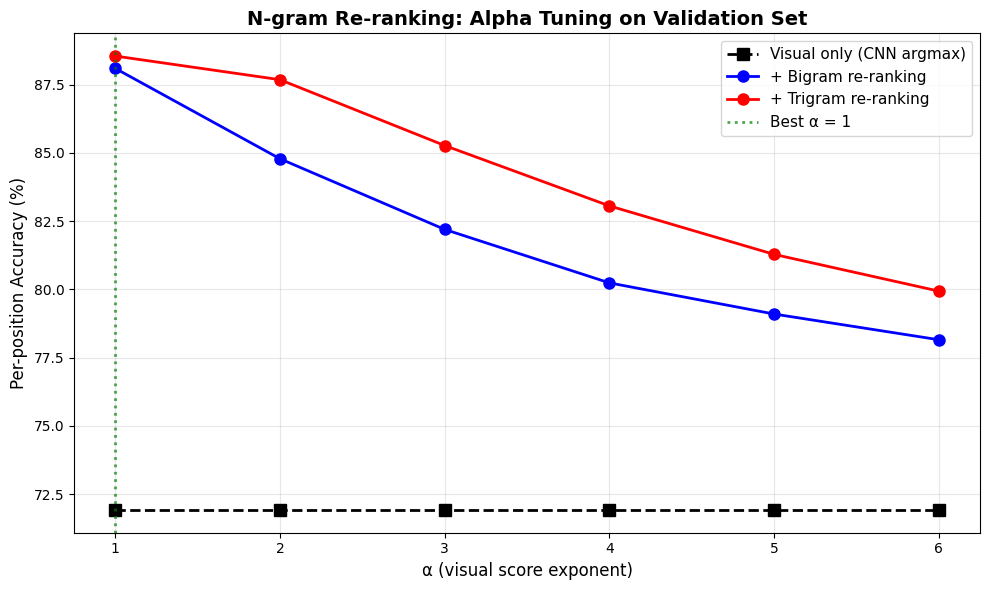

In [11]:
# ── Alpha tuning visualization ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_alpha['alpha'], df_alpha['visual_acc']*100,  'k--s', lw=2, ms=8, label='Visual only (CNN argmax)')
ax.plot(df_alpha['alpha'], df_alpha['bigram_acc']*100,  'b-o',  lw=2, ms=8, label='+ Bigram re-ranking')
ax.plot(df_alpha['alpha'], df_alpha['trigram_acc']*100, 'r-o',  lw=2, ms=8, label='+ Trigram re-ranking')
ax.axvline(BEST_ALPHA, color='green', linestyle=':', lw=2, alpha=0.7, label=f'Best α = {BEST_ALPHA:.0f}')

ax.set_xlabel('α (visual score exponent)', fontsize=12)
ax.set_ylabel('Per-position Accuracy (%)', fontsize=12)
ax.set_title('N-gram Re-ranking: Alpha Tuning on Validation Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('alpha_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# **<span style="color: #c9a84c;">𓏏 Section 6 — Final Test Results</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We now evaluate on the **held-out test sequences** using the best α from the validation grid search. We compare three methods: visual-only (Phase 1 baseline), bigram re-ranking, and trigram re-ranking.</span>

In [12]:
# ── Final evaluation on held-out test sequences ───────────────────────────
final_pipe = CNNNgramPipeline(
    resnet, ngram, idx_to_label, label_to_idx,
    eval_tf, DEVICE, K=10, alpha=BEST_ALPHA
)

res_vis = evaluate_pipeline(final_pipe, test_eval, method='visual_only')
res_bi  = evaluate_pipeline(final_pipe, test_eval, method='bigram')
res_tri = evaluate_pipeline(final_pipe, test_eval, method='trigram')

print('=' * 72)
print('  PHASE 2: CNN + N-GRAM — FINAL TEST RESULTS')
print('=' * 72)
print(f'  Test sequences         : {res_vis["n_sequences"]}')
print(f'  Test positions         : {res_vis["n_positions"]}')
print(f'  Best alpha (from val)  : {BEST_ALPHA}')
print()
print(f'  {"Method":<20s}  {"Per-pos Acc":>12s}  {"Macro F1":>10s}  {"Seq Acc":>10s}')
print(f'  {"─"*20}  {"─"*12}  {"─"*10}  {"─"*10}')
print(f'  {"Visual only (CNN)":<20s}  {res_vis["visual_acc"]*100:>11.2f}%  {res_vis["visual_f1"]*100:>9.2f}%  {res_vis["visual_seq_acc"]*100:>9.2f}%')
print(f'  {"+ Bigram":<20s}  {res_bi["reranked_acc"]*100:>11.2f}%  {res_bi["reranked_f1"]*100:>9.2f}%  {res_bi["reranked_seq_acc"]*100:>9.2f}%')
print(f'  {"+ Trigram":<20s}  {res_tri["reranked_acc"]*100:>11.2f}%  {res_tri["reranked_f1"]*100:>9.2f}%  {res_tri["reranked_seq_acc"]*100:>9.2f}%')
print()
print(f'  Δ trigram vs visual    : {res_tri["delta_acc"]*100:+.2f}% accuracy, {res_tri["delta_f1"]*100:+.2f}% F1')
print('=' * 72)

  PHASE 2: CNN + N-GRAM — FINAL TEST RESULTS
  Test sequences         : 1000
  Test positions         : 18555
  Best alpha (from val)  : 1.0

  Method                 Per-pos Acc    Macro F1     Seq Acc
  ────────────────────  ────────────  ──────────  ──────────
  Visual only (CNN)           72.81%      64.05%       1.40%
  + Bigram                    88.43%      80.56%      15.90%
  + Trigram                   89.21%      79.33%      28.00%

  Δ trigram vs visual    : +16.39% accuracy, +15.27% F1


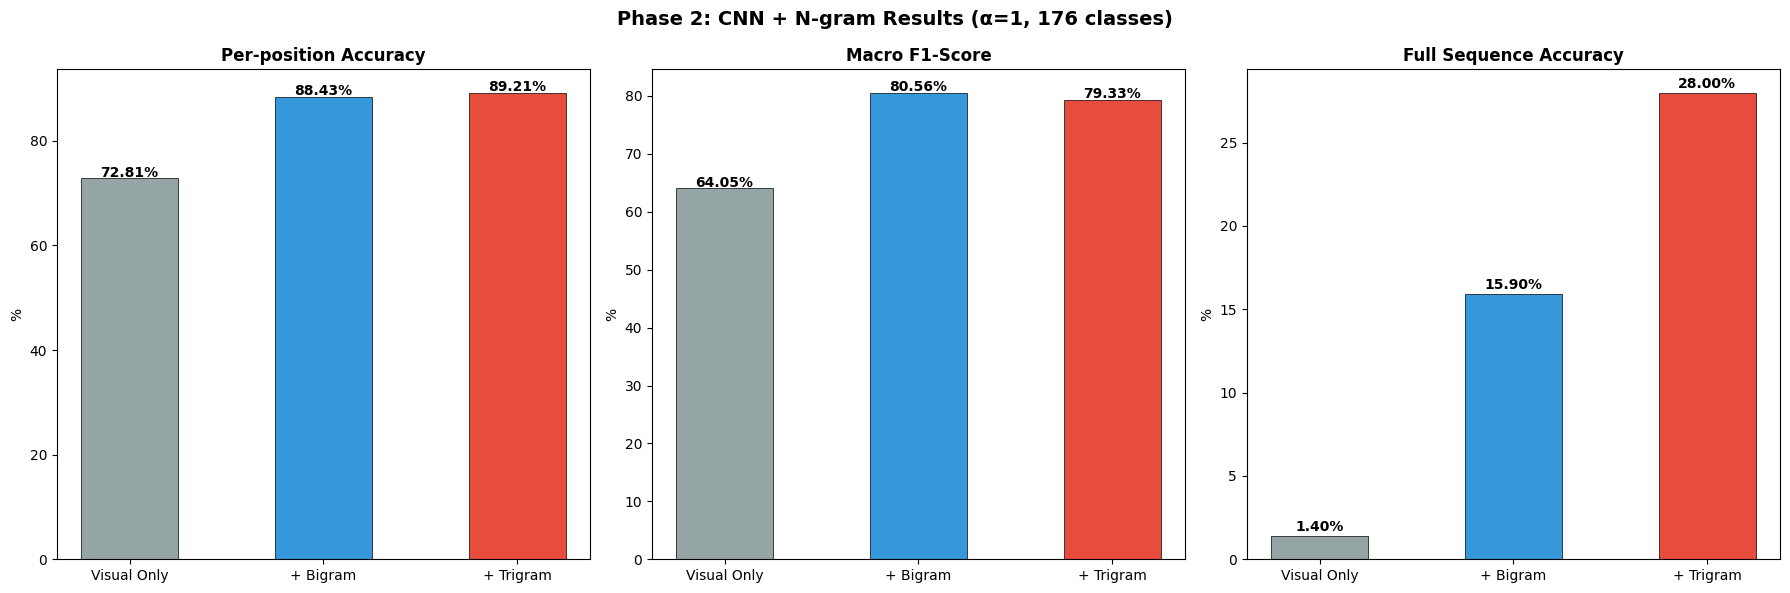

In [13]:
# ── Results visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
methods = ['Visual Only', '+ Bigram', '+ Trigram']
colors  = ['#95a5a6', '#3498db', '#e74c3c']

for ax, vals, title in [
    (axes[0], [res_vis['visual_acc']*100, res_bi['reranked_acc']*100, res_tri['reranked_acc']*100], 'Per-position Accuracy'),
    (axes[1], [res_vis['visual_f1']*100, res_bi['reranked_f1']*100, res_tri['reranked_f1']*100], 'Macro F1-Score'),
    (axes[2], [res_vis['visual_seq_acc']*100, res_bi['reranked_seq_acc']*100, res_tri['reranked_seq_acc']*100], 'Full Sequence Accuracy'),
]:
    bars = ax.bar(methods, vals, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=12); ax.set_ylabel('%')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle(f'Phase 2: CNN + N-gram Results (α={BEST_ALPHA:.0f}, {NUM_CLASSES} classes)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('phase2_results.png', dpi=150, bbox_inches='tight'); plt.show()

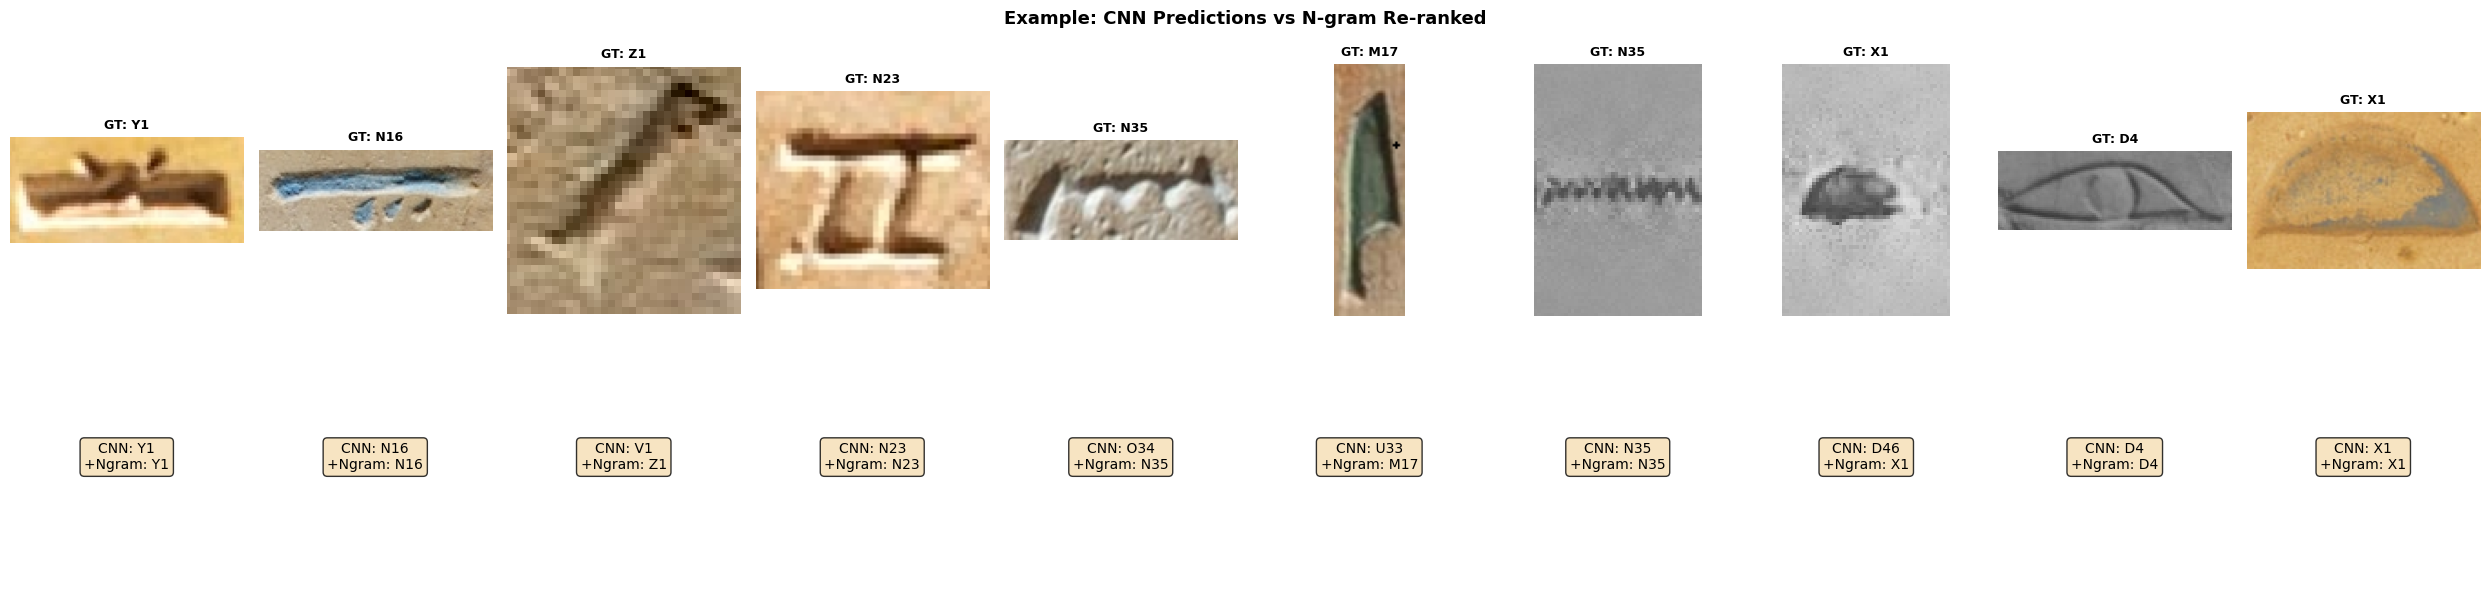

In [14]:
# ── Example: show a sequence with visual vs re-ranked predictions ─────────
if test_eval:
    ex = test_eval[0]
    vis_p, tri_p = final_pipe.predict_sequence(ex['images'], method='trigram')
    true_l = ex['labels']
    
    n_show = min(10, len(true_l))
    fig, axes = plt.subplots(2, n_show, figsize=(2.5*n_show, 6))
    if n_show == 1: axes = axes.reshape(2, 1)
    
    for i in range(n_show):
        axes[0, i].imshow(ex['images'][i]); axes[0, i].axis('off')
        gt = idx_to_label[true_l[i]].upper()
        axes[0, i].set_title(f'GT: {gt}', fontsize=9, fontweight='bold')
        
        vl = idx_to_label[vis_p[i]].upper()
        tl = idx_to_label[tri_p[i]].upper()
        vc = 'green' if vis_p[i] == true_l[i] else 'red'
        tc = 'green' if tri_p[i] == true_l[i] else 'red'
        text = f'CNN: {vl}\n+Ngram: {tl}'
        axes[1, i].text(0.5, 0.5, text, ha='center', va='center', fontsize=10,
                        transform=axes[1, i].transAxes,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        axes[1, i].axis('off')
    
    plt.suptitle('Example: CNN Predictions vs N-gram Re-ranked', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('phase2_example.png', dpi=150, bbox_inches='tight'); plt.show()

# **<span style="color: #c9a84c;">𓊹 Section 7 — Cross-Phase Comparison</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [15]:
# ── Cross-phase comparison ────────────────────────────────────────────────
comp = pd.DataFrame({
    'Phase': ['Phase 1: resnet (isolated)', 'Phase 1: ConvNeXt (isolated)',
              'Phase 2: resnet + Bigram', 'Phase 2: resnet + Trigram'],
    'Context': ['None', 'None', 'Bigram (1 prev sign)', 'Trigram (2 prev signs)'],
    'Per-pos Acc': ['82.66%', '56.23%',
                    f'{res_bi["reranked_acc"]*100:.2f}%', f'{res_tri["reranked_acc"]*100:.2f}%'],
    'Macro F1': ['67.68%', '52.72%',
                 f'{res_bi["reranked_f1"]*100:.2f}%', f'{res_tri["reranked_f1"]*100:.2f}%'],
    'Trainable Params': ['568K', '28.6M', '0 (count-based)', '0 (count-based)'],
})
print(comp.to_string(index=False))

                       Phase                Context Per-pos Acc Macro F1 Trainable Params
  Phase 1: resnet (isolated)                   None      82.66%   67.68%             568K
Phase 1: ConvNeXt (isolated)                   None      56.23%   52.72%            28.6M
    Phase 2: resnet + Bigram   Bigram (1 prev sign)      88.43%   80.56%  0 (count-based)
   Phase 2: resnet + Trigram Trigram (2 prev signs)      89.21%   79.33%  0 (count-based)


# **<span style="color: #c9a84c;"> Section 8 — Save Artifacts</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [16]:
SAVE_DIR = Path('/kaggle/working')

phase2_results = {
    'best_alpha': float(BEST_ALPHA),
    'num_classes': NUM_CLASSES,
    'test_sequences': res_vis['n_sequences'],
    'test_positions': res_vis['n_positions'],
    'visual_only': {'per_pos_acc': float(res_vis['visual_acc']), 'macro_f1': float(res_vis['visual_f1']), 'seq_acc': float(res_vis['visual_seq_acc'])},
    'bigram':      {'per_pos_acc': float(res_bi['reranked_acc']), 'macro_f1': float(res_bi['reranked_f1']), 'seq_acc': float(res_bi['reranked_seq_acc'])},
    'trigram':     {'per_pos_acc': float(res_tri['reranked_acc']), 'macro_f1': float(res_tri['reranked_f1']), 'seq_acc': float(res_tri['reranked_seq_acc'])},
}

with open(SAVE_DIR / 'phase2_results.json', 'w') as f:
    json.dump(phase2_results, f, indent=2)

print('Artifacts saved:')
for f in sorted(SAVE_DIR.glob('*')):
    if f.suffix in ['.json', '.png']: print(f'  {f.name}')
print('\n✓ Phase 2 complete.')

Artifacts saved:
  alpha_tuning.png
  phase2_example.png
  phase2_results.json
  phase2_results.png

✓ Phase 2 complete.
